# Ограничительность документации, конкуренция и стоимость

H3: Более ограничительная тендерная документация связана с меньшей конкуренцией и/или более высокой удельной стоимостью

H5: Часть связи ограничительность -> стоимость объясняется конкуренцией (медиаторная роль)

Источник данных: структурные параметры закупок из `marker_results_main_clean.csv`, стоимостные показатели из `analysis_objects_core.csv`

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy import stats

Загружаю данные

In [17]:
df_raw = pd.read_csv("data_processed/marker_results_main_clean.csv")
df_obj = pd.read_csv("data_processed/analysis_objects_core.csv")

print(f"Публикаций: {len(df_raw)},  объектов в финальной выборке: {len(df_obj)}")

Публикаций: 157,  объектов в финальной выборке: 61


### Переменные ограничительности

Сруктурные параметры тендера - это хорошие прокси ограничительности, когда «требования к участникам» в документации — это юридический текст, из которого сложно надежно извлечь числовые прокси ограничительности (из литературы по закупкам (Szucs 2017, Coviello & Mariniello 2014)). Использую четыре переменные:

* `bid_sec_pct` — обеспечение заявки, % — финансовый барьер входа
* `cont_sec_pct` — обеспечение контракта, % — доп финансовая нагрузка
* `deadline_inv` — срок подачи (инверсия) — короткий срок = меньше времени у аутсайдеров
* `banking` — банковское сопровождение — требует уполномоченного банка-агента

In [18]:
df_raw["date_pub"]  = pd.to_datetime(df_raw["Дата публикации"],
                                      unit="d", origin="1899-12-30", errors="coerce")
df_raw["date_dead"] = pd.to_datetime(
    df_raw["Дата окончания приема заявок / Дата планового окончания исполнения контракта / Плановая дата публикации лота по ППГ"],
    unit="d", origin="1899-12-30", errors="coerce")
df_raw["deadline_days"] = (df_raw["date_dead"] - df_raw["date_pub"]).dt.days

df_raw["bid_sec_pct"] = df_raw["Обеспечение заявки, %"]
df_raw["cont_sec_pct"] = df_raw["Обеспечение контракта, %"]
df_raw["deadline_inv"] = -df_raw["deadline_days"] # выше (меньше времени) = более ограничительно
banking_col = "Банковское \\ казначейское сопровождение"
df_raw["banking"] = df_raw[banking_col].str.contains("банковское", case=False, na=False).astype(float)

In [19]:
df_raw["is_contest"] = df_raw["Тип торгов"].map({"Конкурс открытый": 1.0, "Аукцион электронный": 0.0})

VARS = ["bid_sec_pct", "cont_sec_pct", "deadline_inv", "banking"]
print(df_raw[VARS + ["is_contest"]].describe().round(3))

       bid_sec_pct  cont_sec_pct  deadline_inv  banking  is_contest
count      152.000       145.000       157.000  157.000     105.000
mean         0.027         0.123       -14.261    0.312       0.505
std          0.020         0.108         8.157    0.465       0.502
min          0.010         0.010       -69.000    0.000       0.000
25%          0.010         0.050       -16.000    0.000       0.000
50%          0.010         0.100       -15.000    0.000       1.000
75%          0.050         0.100        -8.000    1.000       1.000
max          0.050         0.500         0.000    1.000       1.000


### Распределения и корреляции

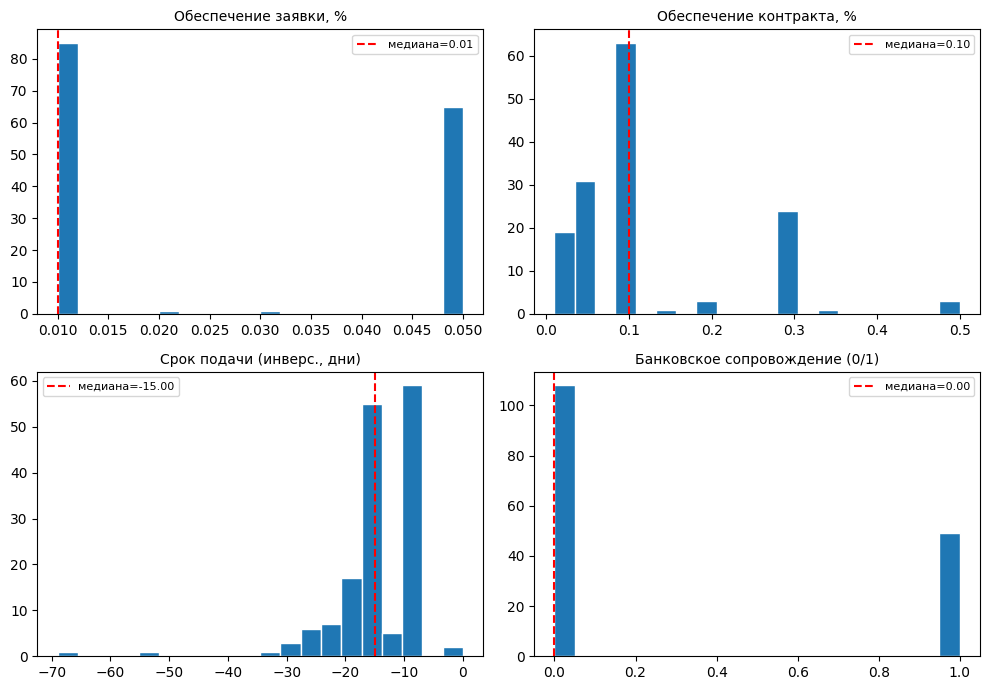

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, var, title in zip(axes.flat, VARS,
    ["Обеспечение заявки, %", "Обеспечение контракта, %",
     "Срок подачи (инверс., дни)", "Банковское сопровождение (0/1)"]):
    data = df_raw[var].dropna()
    ax.hist(data, bins=20, edgecolor="white")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("")
    ax.axvline(data.median(), color="red", linestyle="--", label=f"медиана={data.median():.2f}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

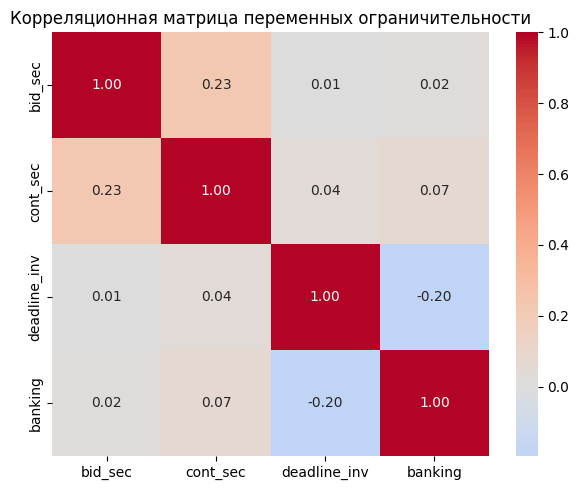

In [21]:
corr = df_raw[VARS].corr()
fig, ax = plt.subplots(figsize=(6, 5))
labels = ["bid_sec", "cont_sec", "deadline_inv", "banking"]
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title("Корреляционная матрица переменных ограничительности")
plt.tight_layout()
plt.show()

**Вывод из EDA:**  
- `bid_sec_pct` и `cont_sec_pct` скоррелированы (финансовые гарантии идут вместе)  
- `deadline_inv` слабо коррелирует с остальными (максимум −0.2 с `banking`): объекты с банковским сопровождением имеют срок подачи короче
- `banking` слабо связан с финансовыми гарантиями

Переменные разнородны, поэтому буду использовать PCA для построения составного индекса ограничительности

### Агрегирую на уровень объекта

Для объектов с несколькими публикациями берем первую по дате — она отражает исходные условия заказчика до возможных перевыпусков тендера

In [22]:
def parse_regnums(s):
    return [x.strip() for x in str(s).split(";") if x.strip()]

ALL_VARS = VARS + ["is_contest"]
rows = []
for _, obj in df_obj.iterrows():
    regnums = parse_regnums(obj["registry_numbers"])
    pubs = df_raw[df_raw["registry_number"].astype(str).isin(regnums)].copy()
    row = {"object_id": obj["object_id"]}

    if len(pubs) == 0:
        for v in ALL_VARS:
            row[v] = np.nan
    else:
        first = pubs.sort_values("date_pub").iloc[0]
        for v in ALL_VARS:
            row[v] = first[v] if pd.notna(first[v]) else np.nan

    rows.append(row)

df_r = pd.DataFrame(rows)
df_merged = df_obj.merge(df_r, on="object_id")

print(f"Объектов всего: {len(df_merged)}")
print(f"Пропуски по переменным PCA:")
print(df_merged[VARS].isna().sum())

Объектов всего: 61
Пропуски по переменным PCA:
bid_sec_pct     1
cont_sec_pct    7
deadline_inv    0
banking         0
dtype: int64


In [23]:
print(f"Пропуски is_contest: {df_merged['is_contest'].isna().sum()}")

Пропуски is_contest: 18


Почему is_contest не в PCA:

In [24]:
sub_check = df_merged.dropna(subset=VARS)
sub_with = df_merged.dropna(subset=VARS + ['is_contest'])

r_pe, p_pe = stats.pearsonr(
    df_merged[['is_contest','deadline_inv']].dropna()['is_contest'],
    df_merged[['is_contest','deadline_inv']].dropna()['deadline_inv']
)
r_sp, p_sp = stats.spearmanr(
    df_merged[['is_contest','deadline_inv']].dropna()['is_contest'],
    df_merged[['is_contest','deadline_inv']].dropna()['deadline_inv']
)
print(f'Пирсон is_contest х deadline_inv: r = {r_pe:.3f}  p = {p_pe:.4f}')
print(f'Спирмен is_contest х deadline_inv: r = {r_sp:.3f}  p = {p_sp:.4f}')
print(f'Объектов в PCA (без is_contest): {len(sub_check)}')
print(f'Объектов с is_contest non-null: {len(sub_with)}')
print(f'Потеря: {len(sub_check) - len(sub_with)}')

Пирсон is_contest х deadline_inv: r = -0.666  p = 0.0000
Спирмен is_contest х deadline_inv: r = -0.646  p = 0.0000
Объектов в PCA (без is_contest): 54
Объектов с is_contest non-null: 39
Потеря: 15


Не включаю в PCA: сильная корреляция с deadline_inv (r=-0.67), потеря 15 наблюдений. Буду использовать как отдельный регрессор в H3/H5

In [25]:
print(f"Полных наблюдений (все 4 переменные): {df_merged[VARS].notna().all(axis=1).sum()}")

Полных наблюдений (все 4 переменные): 54


### Построение индекса ограничительности

Применяю PCA к стандартизованным переменным. Первая главная компонента PC1 — это линейная комбинация с максимальной дисперсией, которая и будет индексом `restrict_idx`. Рабочая выборка для PCA состоит из 60 объектов

In [26]:
sub = df_merged.dropna(subset=VARS).copy()

X = sub[VARS].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

print(f"Доля объяснённой дисперсии по компонентам:")
for i, ev in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {ev*100:.1f}%")

Доля объяснённой дисперсии по компонентам:
  PC1: 35.8%
  PC2: 26.5%
  PC3: 21.7%
  PC4: 16.0%


Вклад каждой переменной в компоненту:

In [27]:
df_loadings = pd.DataFrame(pca.components_.T, index=VARS, 
                           columns=[f'PC{i+1}' for i in range(pca.components_.shape[0])])
print(df_loadings.iloc[:, :4].round(3))

                PC1    PC2    PC3    PC4
bid_sec_pct   0.555  0.016  0.716 -0.424
cont_sec_pct  0.644  0.263 -0.083  0.713
deadline_inv -0.011  0.910 -0.220 -0.351
banking       0.526 -0.320 -0.658 -0.434


Финансовые барьеры — это главная ось вариации ограничительности в выборке

* РC1 — финансовая ограничительность (bid/contract security + banking)
* PC2 — временнАя составляющая (срок подачи заявки)

Использую РС1 как основной индекс (35% дисперсии), РС2 тестирую отдельно как проверку устойчивости

In [28]:
sub["pc1"] = X_scaled @ pca.components_[0]
sub["pc2"] = X_scaled @ pca.components_[1]

print("РС1 (финансовый барьер):")
print(sub["pc1"].describe().round(3))

РС1 (финансовый барьер):
count    54.000
mean      0.000
std       1.207
min      -1.780
25%      -0.953
50%      -0.160
75%       0.967
max       3.490
Name: pc1, dtype: float64


In [29]:
print("РС2 (срок подачи):")
print(sub["pc2"].describe().round(3))

РС2 (срок подачи):
count    54.000
mean      0.000
std       1.040
min      -4.611
25%      -0.261
50%       0.139
75%       0.491
max       2.021
Name: pc2, dtype: float64


### Гипотеза H3a: ограничительность и удельная стоимость

H3a: более ограничительная документация (выше `restrict_idx`) -> выше `unit_cost_base`

In [30]:
h3a_pc1 = sub[["pc1", "unit_cost_base"]].dropna()
r_a1, p_a1 = stats.spearmanr(h3a_pc1["pc1"], h3a_pc1["unit_cost_base"])

h3a_pc2 = sub[["pc2", "unit_cost_base"]].dropna()
r_a2, p_a2 = stats.spearmanr(h3a_pc2["pc2"], h3a_pc2["unit_cost_base"])

print(f"H3a — PC1 (финансовый) vs ucb: rho={r_a1:+.3f}  p={p_a1:.3f}  n={len(h3a_pc1)}")
print(f"H3a — PC2 (временной) vs ucb: rho={r_a2:+.3f}  p={p_a2:.3f}  n={len(h3a_pc2)}")

H3a — PC1 (финансовый) vs ucb: rho=+0.034  p=0.809  n=52
H3a — PC2 (временной) vs ucb: rho=-0.141  p=0.317  n=52


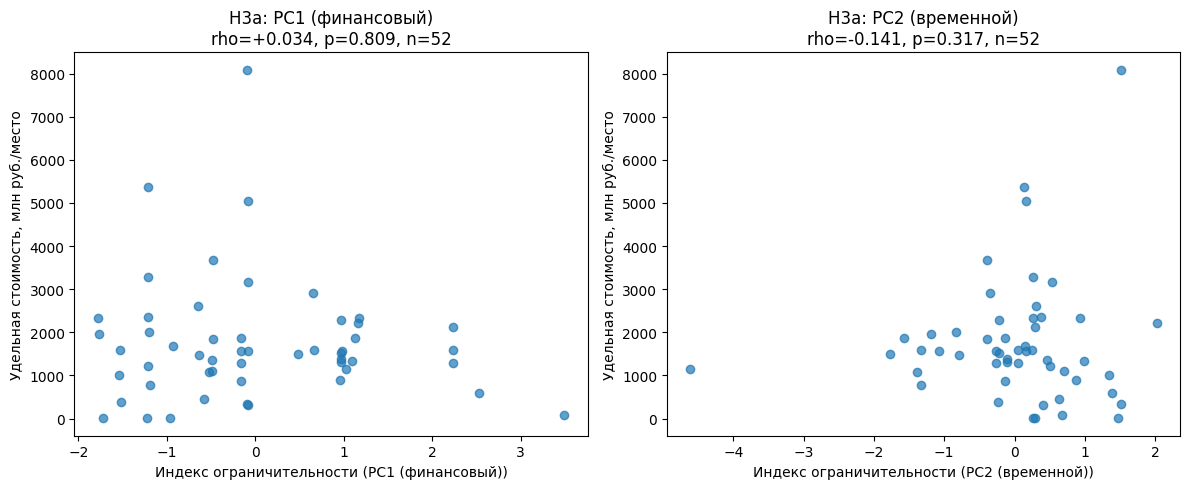

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, comp, r, p, label in zip(axes,
        ["pc1", "pc2"], [r_a1, r_a2], [p_a1, p_a2],
        ["PC1 (финансовый)", "PC2 (временной)"]):
    data = sub[[comp, "unit_cost_base"]].dropna()
    ax.scatter(data[comp], data["unit_cost_base"] / 1000, alpha=0.7)
    ax.set_xlabel(f"Индекс ограничительности ({label})")
    ax.set_ylabel("Удельная стоимость, млн руб./место")
    ax.set_title(f"H3a: {label}\nrho={r:+.3f}, p={p:.3f}, n={len(data)}")
plt.tight_layout()
plt.show()

### Гипотеза H3b: ограничительность и конкуренция

H3b: более ограничительная документация -> меньшее снижение от НМЦК (`discount_pct_mean`). Ожидаемый знак - `rho < 0`

In [32]:
h3b_pc1 = sub[["pc1", "discount_pct_mean"]].dropna()
r_b1, p_b1 = stats.spearmanr(h3b_pc1["pc1"], h3b_pc1["discount_pct_mean"])

h3b_pc2 = sub[["pc2", "discount_pct_mean"]].dropna()
r_b2, p_b2 = stats.spearmanr(h3b_pc2["pc2"], h3b_pc2["discount_pct_mean"])

print(f"H3b — PC1 (финансовый) vs discount: rho={r_b1:+.3f}  p={p_b1:.3f}  n={len(h3b_pc1)}")
print(f"H3b — PC2 (временной) vs discount: rho={r_b2:+.3f}  p={p_b2:.3f}  n={len(h3b_pc2)}")

H3b — PC1 (финансовый) vs discount: rho=-0.556  p=0.006  n=23
H3b — PC2 (временной) vs discount: rho=-0.245  p=0.261  n=23


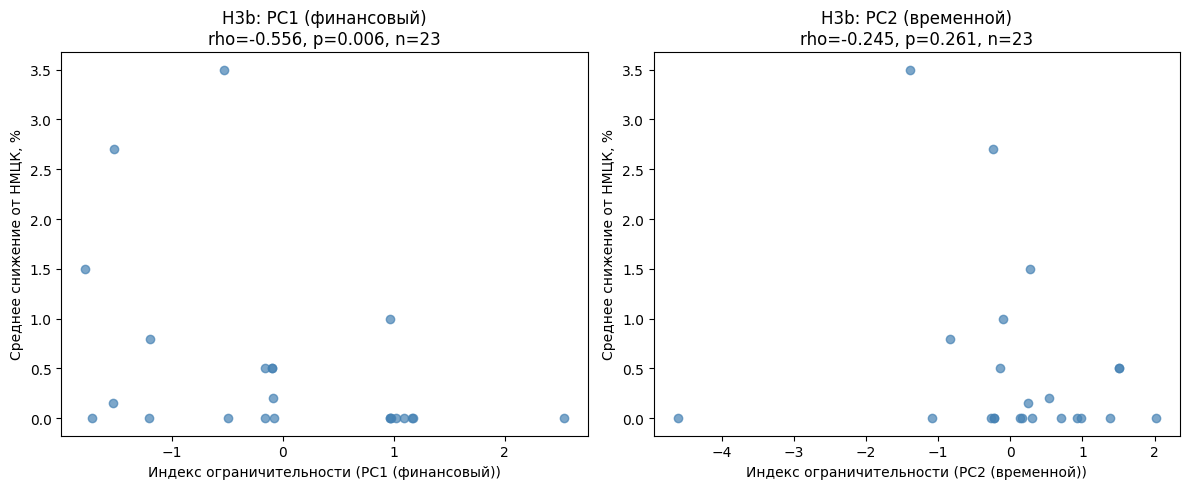

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, comp, r, p, label in zip(axes,
        ["pc1", "pc2"], [r_b1, r_b2], [p_b1, p_b2],
        ["PC1 (финансовый)", "PC2 (временной)"]):
    data = sub[[comp, "discount_pct_mean"]].dropna()
    ax.scatter(data[comp], data["discount_pct_mean"] * 100, alpha=0.7, color="steelblue")
    ax.set_xlabel(f"Индекс ограничительности ({label})")
    ax.set_ylabel("Среднее снижение от НМЦК, %")
    ax.set_title(f"H3b: {label}\nrho={r:+.3f}, p={p:.3f}, n={len(data)}")
plt.tight_layout()
plt.show()

### Гипотеза H5: медиаторная роль конкуренции

H5: связь «ограничительность -> стоимость» частично объясняется конкуренцией

Стандартный медиационный анализ требует наличия значимого прямого эффекта `restrict_idx -> ucb`, а так как H3a не подтвердилась, формальный тест медиации не применим. Попробую проверить путь через конкуренцию: `restrict_idx -> discount_pct -> ucb`

Есть ли связь discount_pct -> ucb: 

In [34]:
import statsmodels.formula.api as smf

h5 = sub[["pc1", "discount_pct_mean", "unit_cost_base"]].dropna()
r_disc_ucb, p_disc_ucb = stats.spearmanr(h5["discount_pct_mean"], h5["unit_cost_base"])
print(f"discount_pct -> ucb: rho={r_disc_ucb:.3f}  p={p_disc_ucb:.3f}  n={len(h5)}")

discount_pct -> ucb: rho=-0.024  p=0.917  n=22


Стат значимой связи нет

3 модели (прямой эффект, медиатор, полная):

In [35]:
m1 = smf.ols("unit_cost_base ~ pc1", data=h5).fit()
m2 = smf.ols("discount_pct_mean ~ pc1", data=h5).fit()
m3 = smf.ols("unit_cost_base ~ pc1 + discount_pct_mean", data=h5).fit()

print("Модель 1: ucb ~ pc1")
print(f"  coef={m1.params['pc1']:.1f}  p={m1.pvalues['pc1']:.3f}  R²={m1.rsquared:.3f}")

print("\nМодель 2: discount_pct ~ pc1")
print(f"  coef={m2.params['pc1']:.4f}  p={m2.pvalues['pc1']:.3f}  R²={m2.rsquared:.3f}")

print("\nМодель 3: ucb ~ pc1 + discount_pct")
print(f"  pc1: coef={m3.params['pc1']:.1f}  p={m3.pvalues['pc1']:.3f}")
print(f"  discount_pct: coef={m3.params['discount_pct_mean']:.1f}  p={m3.pvalues['discount_pct_mean']:.3f}")
print(f"  R²={m3.rsquared:.3f}")

Модель 1: ucb ~ pc1
  coef=-127404.6  p=0.723  R²=0.006

Модель 2: discount_pct ~ pc1
  coef=-0.0031  p=0.067  R²=0.158

Модель 3: ucb ~ pc1 + discount_pct
  pc1: coef=-289852.0  p=0.461
  discount_pct: coef=-51666162.2  p=0.302
  R²=0.062


### Доп анализ: тип процедуры (конкурс vs аукцион)

`is_contest` — бинарная переменная (1 = открытый конкурс, 0 = электронный аукцион) — не включалась в PCA из-за сильной отрицательной корреляции с `deadline_inv` (r = −0.67): конкурсы, как правило, дают участникам больше времени на подготовку заявки, но при этом они потенциально более ограничительны: оцениваться может больше критериев (опыт, квалификация) - а это барьеры для новых участников

Проверяю, связана ли форма закупки (конкурс vs аукцион) с удельной стоимостью и уровнем ценового снижения

In [38]:
h5_ext = sub[["pc1", "discount_pct_mean", "unit_cost_base", "is_contest"]].dropna(subset=["pc1","unit_cost_base"])
print(f"Наблюдений: {len(h5_ext)}, с известным is_contest: {h5_ext['is_contest'].notna().sum()}")

Наблюдений: 52, с известным is_contest: 37


Средняя удельная стоимость по типу (аукцион=0, конкурс=1):

In [40]:
print(h5_ext.groupby("is_contest")["unit_cost_base"].agg(["mean","median","count"]).round(0))

                 mean     median  count
is_contest                             
0.0         1197990.0  1092460.0      9
1.0         1611617.0  1574274.0     28


Корреляции:

In [41]:
rn = h5_ext["is_contest"].notna()
r_ic_ucb, p_ic_ucb = stats.spearmanr(
    h5_ext.loc[rn,"is_contest"], h5_ext.loc[rn,"unit_cost_base"])
r_ic_disc, p_ic_disc = stats.spearmanr(
    h5_ext.loc[rn & h5_ext["discount_pct_mean"].notna(),"is_contest"],
    h5_ext.loc[rn & h5_ext["discount_pct_mean"].notna(),"discount_pct_mean"])
print(f"is_contest -> unit_cost_base: rho={r_ic_ucb:+.3f}  p={p_ic_ucb:.3f}")
print(f"is_contest -> discount_pct: rho={r_ic_disc:+.3f}  p={p_ic_disc:.3f}")

is_contest -> unit_cost_base: rho=+0.236  p=0.160
is_contest -> discount_pct: rho=+0.488  p=0.220


Регрессия ucb ~ pc1 + is_contest (без требования discount_pct):

In [46]:
h5_ic2 = h5_ext.dropna(subset=["is_contest"])
m4 = smf.ols("unit_cost_base ~ pc1 + is_contest", data=h5_ic2).fit()
print(f"Модель 4: ucb ~ pc1 + is_contest (n={len(h5_ic2)})")
print(f"  pc1: coef={m4.params['pc1']:.1f}  p={m4.pvalues['pc1']:.3f}")
print(f"  is_contest: coef={m4.params['is_contest']:.1f}  p={m4.pvalues['is_contest']:.3f}")
print(f"  R²={m4.rsquared:.3f}")

Модель 4: ucb ~ pc1 + is_contest (n=37)
  pc1: coef=-39457.0  p=0.721
  is_contest: coef=404725.1  p=0.229
  R²=0.048


### Итоги по гипотезам H3 и H5

- H3b подтверждена для PC1: высокие требования к обеспечению отсеивают финансово неустойчивых участников. Ограничение претендентов по оборотному капиталу закономерно снижает ценовую конкуренцию на аукционах

- PC2 (временной барьер) не связан ни с удельной стоимостью, ни с конкуренцией

- H3a не подтверждена: PC1 напрямую не связан с удельной стоимостью

- H5 не подтверждена: медиация через скидку статистически незначима (выборка n = 22 для полной модели очень маленькая)

- Тип процедуры (конкурс vs аукцион): есть стат значимая связь между форматом закупки и уровнем экономии — конкурсы дают большее снижение цены по сравнению с аукционами. Возможно тут работает механизм ценовой компенсации: в условиях борьбы за суммарный балл участники вынуждены предлагать более низкую цену, чтобы не отставать от конкурентов по качественным характеристикам объекта или квалификации

**Ограничения:**

- Данные о количестве участников доступны для 22 объектов из 54 → медиационная цепочка (H5) недостаточно мощна
- PC1 объясняет лишь 35.8% дисперсии — индекс охватывает финансовые, но не содержательные требования
- is_contest доступен для 39 из 54 объектов в PCA-выборке, что ограничивает анализ типа процедуры
- Индекс измеряет структурные параметры тендера (обеспечение, сроки, сопровождение), а не содержание квалификационных требований